# Dia 2 · Módulo 5 — Regressão
### Estatística Básica Aplicada · Python

O Módulo 4 terminou com uma limitação incômoda: o `r` diz que duas variáveis **andam juntas**,
mas não diz **quanto** uma se move quando a outra se move — e não permite prever um caso novo.
Isso é justamente o que o comando pergunta:

> ## Se eu aumentar o treino em 2 horas, o tempo de corrida cai quanto?
> ## E quanto vale a previsão que eu fizer para um militar específico?

**O que a turma vai levar deste módulo:**
1. Mínimos quadrados **é a régua do quadrado do Módulo 1** — a reta é a média, generalizada.
2. O coeficiente (inclinação da reta) tem **unidade** e responde "sobe quanto"; o `r` não responde isso.
3. O coeficiente **muda** quando você acrescenta outra variável — e essa é a porta do Módulo 6.
4. **Os resíduos são o diagnóstico.** É neles que a reta confessa se tinha o direito de existir.
5. **Regressão à média**: o fenômeno que faz o comando premiar e punir por puro acaso.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | O mesmo `r`, decisões opostas | o `r` não mede o **tamanho** do efeito |
| ① | De onde vem a reta | é o contrato A do Módulo 1, com uma reta no lugar de um número |
| ② | Lendo um coeficiente | unidade, intercepto e "mantendo o resto constante" |
| ③ | Os resíduos | onde a reta confessa |
| ④ | Extrapolação | prever fora da faixa medida |
| ⑤ | Regressão à média | o efeito que não existiu |
| ⑥ | Decisão: prever ≠ explicar | |

A seção ⑤ é a que mais muda decisão de comando na prática — se o tempo apertar, **não** é ela
que deve cair.

In [1]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

COR = {
    "media":    "#2a78d6",   # azul
    "mediana":  "#eb6834",   # laranja
    "dados":    "#9ec5f4",   # azul claro (nuvem de pontos)
    "reta":     "#2a78d6",   # azul      — a reta ajustada
    "residuo":  "#4a3aa7",   # violeta   — o que sobra do ajuste
    "alerta":   "#e34948",   # vermelho  — o que estraga a conta
    "verdade":  "#1baf7a",   # verde     — o valor real, quando o conhecemos
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

# --- A MESMA companhia do Módulo 4 (mesma semente = mesmos militares) ---
rng = np.random.default_rng(7)
N = 80

idade  = rng.integers(19, 46, N)
horas  = np.clip(rng.normal(6.5, 1.8, N) - 0.04 * (idade - 30), 1.0, None)
tempo  = 11.2 + 0.055 * (idade - 19) - 0.30 * horas + rng.normal(0, 0.55, N)
flex   = 52.0 - 0.45 * (idade - 19) + 1.9 * horas + rng.normal(0, 3.0, N)

cia = pd.DataFrame({
    "militar": [f"M{i:02d}" for i in range(1, N + 1)],
    "idade": idade,
    "horas_treino": horas.round(1),
    "tempo_corrida_min": tempo.round(2),
    "flexoes": flex.round(0).astype(int),
})

h = cia["horas_treino"].to_numpy()
t = cia["tempo_corrida_min"].to_numpy()
i_ = cia["idade"].to_numpy()

print("Ambiente pronto. Companhia de 80 militares (a mesma do Módulo 4).")

Ambiente pronto. Companhia de 80 militares (a mesma do Módulo 4).


---
# ⓪ O mesmo `r`, decisões opostas

Duas OMs mandam seus estudos sobre horas de treino × tempo de corrida. **As duas reportam
`r = −0,85`** — mesma força, mesmo sinal (mais treino, menos tempo). O comando conclui que o
efeito do treino é igual nas duas e padroniza a carga para todo mundo.

**Antes de rodar:** duas amostras com o mesmo `r` precisam ter o mesmo efeito prático?

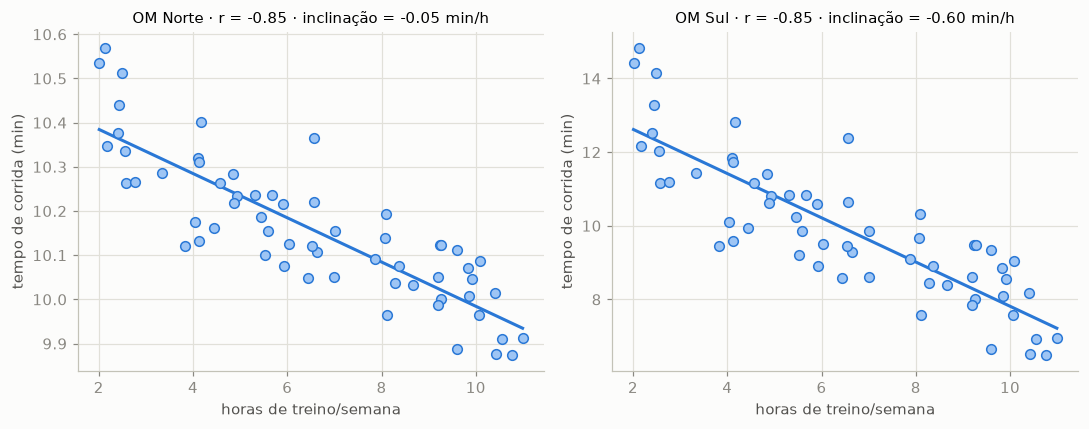

OM Norte: r = -0.85 | 2 h de treino a mais mudam o tempo em -0.10 min
OM Sul: r = -0.85 | 2 h de treino a mais mudam o tempo em -1.20 min

MESMO r. Na OM Norte, dobrar o esforço de treino ganha 6 segundos — não vale a pena.
Na OM Sul, as mesmas 2 h ganham mais de 1 minuto — muda a classificação do militar.

O r mede o quanto os pontos GRUDAM na reta. Não mede o quanto a reta SOBE.
Quem decide operação é a inclinação, e ela tem unidade: minutos por hora de treino.


In [2]:
# --- Mesmo r, efeitos práticos completamente diferentes ---
rng0 = np.random.default_rng(5)
hx = rng0.uniform(2, 11, 60)
ruido = rng0.normal(0, 1, 60)

# construímos as duas para terem o MESMO r (-0,80), mudando só a INCLINAÇÃO.
# o truque: o ruído é proporcional ao efeito, então a razão sinal/ruído — que é o r — não muda
y_om1 = 10.5 - 0.05 * hx + 0.75 * 0.05 * hx.std() * ruido    # efeito minúsculo
y_om2 = 14.0 - 0.60 * hx + 0.75 * 0.60 * hx.std() * ruido    # efeito grande

fig, (e1, e2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for eixo, yy, nome in [(e1, y_om1, "OM Norte"), (e2, y_om2, "OM Sul")]:
    a, b = np.polyfit(hx, yy, 1)
    eixo.scatter(hx, yy, color=COR["dados"], edgecolor=COR["reta"], s=40, zorder=3)
    eixo.plot(np.sort(hx), a * np.sort(hx) + b, color=COR["reta"])
    eixo.set_title(f"{nome} · r = {stats.pearsonr(hx, yy).statistic:.2f} · "
                   f"inclinação = {a:.2f} min/h", fontsize=10)
    eixo.set_xlabel("horas de treino/semana"); eixo.set_ylabel("tempo de corrida (min)")
plt.tight_layout()
plt.show()

for nome, yy in [("OM Norte", y_om1), ("OM Sul", y_om2)]:
    a, _ = np.polyfit(hx, yy, 1)
    print(f"{nome}: r = {stats.pearsonr(hx, yy).statistic:.2f} | "
          f"2 h de treino a mais mudam o tempo em {2 * a:+.2f} min")

print("\nMESMO r. Na OM Norte, dobrar o esforço de treino ganha 6 segundos — não vale a pena.")
print("Na OM Sul, as mesmas 2 h ganham mais de 1 minuto — muda a classificação do militar.")
print("\nO r mede o quanto os pontos GRUDAM na reta. Não mede o quanto a reta SOBE.")
print("Quem decide operação é a inclinação, e ela tem unidade: minutos por hora de treino.")

> ### 🔑 A ideia central do módulo
> O `r` é **adimensional** — foi construído assim de propósito (Módulo 4, §①), dividindo pelos
> desvios padrão para poder comparar coisas diferentes. Só que **essa mesma divisão apagou a
> informação operacional**: quantos minutos por hora de treino.
>
> A regressão devolve a unidade. É por isso que ela, e não a correlação, é a ferramenta de
> decisão.

---
# ① De onde vem a reta

Volte ao **jogo do palpite único** do Módulo 1. Lá, o comando pedia **um número** para
representar o pelotão e cobrava multa pelo erro. Com a multa `(erro)²`, o palpite vencedor era a
**média**.

Agora o jogo é o mesmo, com uma única mudança: em vez de um número fixo, seu palpite pode
**depender das horas de treino do militar**. Ou seja, seu palpite virou uma **reta**.

A multa continua sendo a mesma: a soma dos erros ao quadrado. Vamos de novo procurar o vencedor
na **força bruta**, testando milhares de retas.

In [2]:
# --- Força bruta: qual reta paga a menor multa? ---
inclinacoes = np.linspace(-0.8, 0.2, 401)     # candidatos a "minutos por hora de treino"
interceptos = np.linspace(8.0, 13.0, 401)     # candidatos a "tempo quando horas = 0"

# multa de cada combinação (a, b): soma dos erros ao quadrado
A, B = np.meshgrid(inclinacoes, interceptos, indexing="ij")
previsto = A[:, :, None] * h[None, None, :] + B[:, :, None]
multa = ((t[None, None, :] - previsto) ** 2).sum(axis=2)

ia, ib = np.unravel_index(multa.argmin(), multa.shape)
a_bruta, b_bruta = inclinacoes[ia], interceptos[ib]

a_formula, b_formula = np.polyfit(h, t, 1)          # a fórmula pronta

print("VENCEDOR DA FORÇA BRUTA (testamos 401 × 401 = 160.801 retas):")
print(f"  inclinação = {a_bruta:>7.3f} min por hora de treino")
print(f"  intercepto = {b_bruta:>7.3f} min")
print()
print("A FÓRMULA PRONTA (np.polyfit — mínimos quadrados):")
print(f"  inclinação = {a_formula:>7.3f}")
print(f"  intercepto = {b_formula:>7.3f}")
print()
print("Mesma reta. 'Mínimos quadrados' é literalmente isto: a reta de multa mínima")
print("quando o erro é cobrado AO QUADRADO — o contrato A do Módulo 1.")

VENCEDOR DA FORÇA BRUTA (testamos 401 × 401 = 160.801 retas):
  inclinação =  -0.390 min por hora de treino
  intercepto =  12.450 min

A FÓRMULA PRONTA (np.polyfit — mínimos quadrados):
  inclinação =  -0.390
  intercepto =  12.453

Mesma reta. 'Mínimos quadrados' é literalmente isto: a reta de multa mínima
quando o erro é cobrado AO QUADRADO — o contrato A do Módulo 1.


melhor palpite constante (força bruta) = 9.9802
média dos tempos                       = 9.9799

A MÉDIA é o caso particular da regressão em que você não tem nenhuma variável
explicativa. A reta de regressão é a média CONDICIONADA às horas de treino:
a melhor estimativa do tempo PARA CADA valor de treino, em vez de uma só para todos.


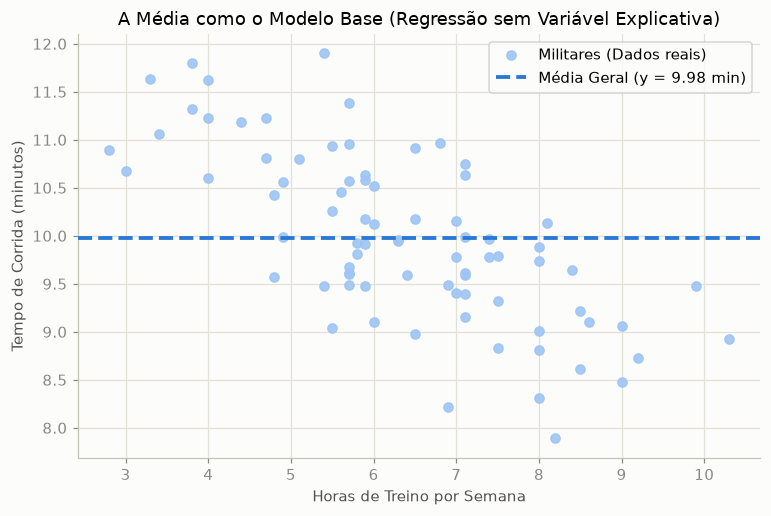

In [5]:
# --- A média é a regressão SEM x ---
# Se o seu palpite não pode depender de nada, a melhor reta é uma reta HORIZONTAL.
# E a altura dela é... a média.
so_constante = np.linspace(t.min(), t.max(), 4001)
multa_const = np.array([np.sum((t - c) ** 2) for c in so_constante])

media_t = t.mean()

print(f"melhor palpite constante (força bruta) = {so_constante[multa_const.argmin()]:.4f}")
print(f"média dos tempos                       = {media_t:.4f}")
print()
print("A MÉDIA é o caso particular da regressão em que você não tem nenhuma variável")
print("explicativa. A reta de regressão é a média CONDICIONADA às horas de treino:")
print("a melhor estimativa do tempo PARA CADA valor de treino, em vez de uma só para todos.")

# --- Gráfico ---
plt.figure(figsize=(8, 5))

# Usando as variáveis que você definiu: 'h' (horas_treino) no eixo X e 't' (tempo) no eixo Y
# Aproveitando o dicionário de cores 'COR'
plt.scatter(h, t, color=COR["dados"], label="Militares (Dados reais)", alpha=0.9, zorder=2)

# Desenhando a reta da média
plt.axhline(y=media_t, color=COR["media"], linestyle="--", linewidth=2.5, 
            label=f"Média Geral (y = {media_t:.2f} min)", zorder=3)

plt.title("A Média como o Modelo Base (Regressão sem Variável Explicativa)")
plt.xlabel("Horas de Treino por Semana")
plt.ylabel("Tempo de Corrida (minutos)")
plt.legend()

plt.show()

> **Por que isso importa mais do que parece:** a regressão herda, item por item, as virtudes e os
> defeitos da média (Módulo 1 e 2).
>
> | Herança | Consequência |
> |---|---|
> | minimiza erro **quadrático** | pune muito o erro grande → **um ponto extremo entorta a reta** |
> | é uma **média condicional** | descreve o **centro**, não o pior caso — planejar pela reta é planejar pela média (Módulo 2, §4.3) |
> | conversa com o **total** | previsões somam: útil para logística |
>
> Se você precisa de robustez, existem regressões robustas — pelo mesmo motivo que existe a
> mediana. É o mesmo dial de sempre.

---
# ② Lendo um coeficiente

## 2.1 · O coeficiente tem unidade — e é ela que responde ao comando

In [5]:
# --- Traduzindo a reta para português ---
a1, b1 = np.polyfit(h, t, 1)

print(f"tempo_previsto = {b1:.3f} + ({a1:.3f}) × horas_treino")
print()
print(f"INCLINAÇÃO {a1:.3f} min/h:")
print(f"  cada hora de treino a mais na semana está associada a {a1:.3f} min no tempo de corrida")
print(f"  (ou seja: {abs(a1) * 60:.0f} segundos a menos por hora semanal de treino)")
print()
print(f"INTERCEPTO {b1:.3f} min:")
print(f"  é o tempo previsto para quem treina ZERO hora por semana.")
print(f"  MAS o militar que menos treina nesta companhia faz {h.min():.1f} h/semana —")
print(f"  ou seja, o intercepto está FORA dos dados. Ele é um artefato matemático,")
print(f"  não uma previsão em que você deva acreditar. (Isso é a seção ④.)")

tempo_previsto = 12.453 + (-0.390) × horas_treino

INCLINAÇÃO -0.390 min/h:
  cada hora de treino a mais na semana está associada a -0.390 min no tempo de corrida
  (ou seja: 23 segundos a menos por hora semanal de treino)

INTERCEPTO 12.453 min:
  é o tempo previsto para quem treina ZERO hora por semana.
  MAS o militar que menos treina nesta companhia faz 2.8 h/semana —
  ou seja, o intercepto está FORA dos dados. Ele é um artefato matemático,
  não uma previsão em que você deva acreditar. (Isso é a seção ④.)


## 2.2 · "Mantendo o restante constante" — e por que o coeficiente muda

Aqui está o fato que mais confunde na leitura de artigos: **o mesmo coeficiente muda de valor
dependendo de quais outras variáveis estão no modelo.** Isso não é erro nem manipulação — é o
significado do coeficiente que muda.

Nesta companhia, os militares mais velhos treinam um pouco menos **e** correm um pouco mais
devagar. Quando você olha só as horas de treino, parte do efeito da **idade** entra escondida
dentro do coeficiente do treino.

**Antes de rodar:** o efeito do treino vai parecer **maior** ou **menor** quando a idade não
estiver no modelo?

In [6]:
# --- O mesmo coeficiente, com e sem a idade no modelo ---
# regressão múltipla na mão: resolve o mesmo problema de mínimos quadrados com 2 variáveis
X_simples = np.column_stack([np.ones(N), h])
X_multipla = np.column_stack([np.ones(N), h, i_])

beta_s = np.linalg.lstsq(X_simples,  t, rcond=None)[0]
beta_m = np.linalg.lstsq(X_multipla, t, rcond=None)[0]

print("MODELO 1 — só horas de treino")
print(f"  efeito do treino: {beta_s[1]:>7.3f} min por hora")
print()
print("MODELO 2 — horas de treino + idade")
print(f"  efeito do treino: {beta_m[1]:>7.3f} min por hora  (mantendo a idade constante)")
print(f"  efeito da idade : {beta_m[2]:>7.3f} min por ano   (mantendo o treino constante)")
print()
print("VERDADE (nós construímos estes dados, então sabemos):")
print("  efeito real do treino: -0.300 min por hora")
print("  efeito real da idade : +0.055 min por ano")
print()
print("O Modelo 1 EXAGERA o efeito do treino. Ele credita ao treino uma parte do que")
print("é, na verdade, idade — porque quem treina menos nesta companhia também é mais velho.")
print("O Modelo 2 separa as duas coisas e chega PERTO dos valores verdadeiros.")
print("\n(Perto, não em cima: o que sobra é o acaso desta amostra de 80. Quanto se espera")
print(" que um coeficiente balance por puro acaso é assunto do Módulo 8.)")

MODELO 1 — só horas de treino
  efeito do treino:  -0.390 min por hora

MODELO 2 — horas de treino + idade
  efeito do treino:  -0.331 min por hora  (mantendo a idade constante)
  efeito da idade :   0.053 min por ano   (mantendo o treino constante)

VERDADE (nós construímos estes dados, então sabemos):
  efeito real do treino: -0.300 min por hora
  efeito real da idade : +0.055 min por ano

O Modelo 1 EXAGERA o efeito do treino. Ele credita ao treino uma parte do que
é, na verdade, idade — porque quem treina menos nesta companhia também é mais velho.
O Modelo 2 separa as duas coisas e chega PERTO dos valores verdadeiros.

(Perto, não em cima: o que sobra é o acaso desta amostra de 80. Quanto se espera
 que um coeficiente balance por puro acaso é assunto do Módulo 8.)


> **O que "mantendo a idade constante" significa de fato:** o coeficiente do treino no Modelo 2
> responde à pergunta *"comparando militares da mesma idade, o que muda com uma hora a mais de
> treino?"*. É uma comparação **dentro** de cada faixa de idade, não entre elas.
>
> ⚠️ **E aqui mora a armadilha que abre o Módulo 6:** o Modelo 2 acertou porque nós colocamos a
> idade nele. Se existisse uma terceira variável relevante que **não** foi medida, o coeficiente
> continuaria enviesado — e **nada no resultado avisaria você disso**. O R², os coeficientes, os
> gráficos: tudo continuaria com aparência perfeitamente saudável.
>
> Um coeficiente de regressão só é um **efeito** se você tiver certeza de que mediu tudo o que
> importa. Fora disso, ele é uma **associação ajustada** — e essa distinção é o Módulo 6 inteiro.

---
# ③ Os resíduos: onde a reta confessa

**Resíduo** = valor real − valor previsto pela reta. É o que a reta **errou** em cada militar.

O gráfico de dispersão original engana com facilidade quando há muitos pontos. O gráfico de
resíduos, não: nele, se a reta estiver correta, os pontos devem ficar espalhados **sem padrão
nenhum** em torno do zero — uma "faixa de ruído" sem forma.

**Qualquer padrão visível no resíduo é a reta dizendo que você usou o modelo errado.**

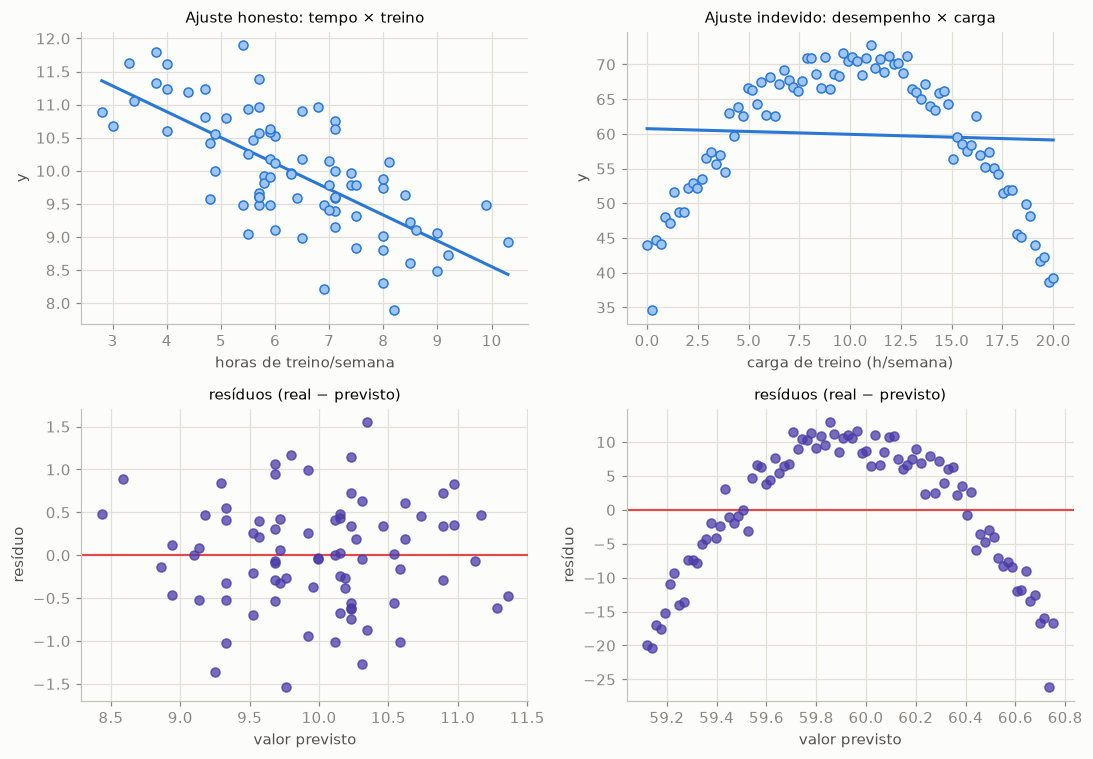

ESQUERDA: resíduos sem forma, espalhados em torno do zero. A reta tinha o direito de existir.
DIREITA : os resíduos desenham um ARCO — negativos nas pontas, positivos no meio.
          A reta está sistematicamente errando na MESMA direção em cada faixa.

O r² do ajuste da direita não denuncia isso. Só o gráfico de resíduos denuncia.


In [7]:
# --- Dois ajustes: um honesto e um que esconde uma curva ---
rng5 = np.random.default_rng(13)
carga = np.linspace(0, 20, 90)
desemp = 40 + 6.0 * carga - 0.30 * carga ** 2 + rng5.normal(0, 2.2, 90)   # o morro do Módulo 4

fig, eixos = plt.subplots(2, 2, figsize=(10, 7))

for col, (xx, yy, titulo, xlab) in enumerate([
    (h, t, "Ajuste honesto: tempo × treino", "horas de treino/semana"),
    (carga, desemp, "Ajuste indevido: desempenho × carga", "carga de treino (h/semana)"),
]):
    aa, bb = np.polyfit(xx, yy, 1)
    prev = aa * xx + bb
    res = yy - prev

    eixos[0, col].scatter(xx, yy, color=COR["dados"], edgecolor=COR["reta"], s=35, zorder=3)
    eixos[0, col].plot(np.sort(xx), aa * np.sort(xx) + bb, color=COR["reta"])
    eixos[0, col].set_title(titulo, fontsize=10)
    eixos[0, col].set_xlabel(xlab); eixos[0, col].set_ylabel("y")

    eixos[1, col].scatter(prev, res, color=COR["residuo"], s=35, alpha=0.75, zorder=3)
    eixos[1, col].axhline(0, color=COR["alerta"], linewidth=1.4)
    eixos[1, col].set_title("resíduos (real − previsto)", fontsize=10)
    eixos[1, col].set_xlabel("valor previsto"); eixos[1, col].set_ylabel("resíduo")

plt.tight_layout()
plt.show()

print("ESQUERDA: resíduos sem forma, espalhados em torno do zero. A reta tinha o direito de existir.")
print("DIREITA : os resíduos desenham um ARCO — negativos nas pontas, positivos no meio.")
print("          A reta está sistematicamente errando na MESMA direção em cada faixa.")
print("\nO r² do ajuste da direita não denuncia isso. Só o gráfico de resíduos denuncia.")

### O que procurar no gráfico de resíduos

| Padrão que você vê | O que significa | O que fazer |
|---|---|---|
| nuvem sem forma em torno do zero | o modelo está adequado | seguir |
| **arco** (U ou ∩) | a relação é **curva** | termo quadrático, ou log (Módulo 3, §⑤) |
| **funil** (espalha à direita) | o erro cresce com o valor | transformar y, ou modelar a variância |
| **um ponto muito longe** | ponto influente | investigar (Módulo 3, §④) — não apagar |
| **degraus ou dois grupos** | há **subgrupos** misturados | separar os grupos (Módulo 3, §⓪) |

> É o mesmo conselho do Dia 1, mudando de endereço: **olhe o histograma antes de resumir; olhe
> os resíduos antes de acreditar no modelo.**

---
# ④ Extrapolação: prever fora da faixa medida

A reta é uma descrição do que aconteceu **na faixa de dados que você mediu**. Nada na matemática
impede você de estender a reta para além dela — e nada na matemática avisa que aquilo virou
ficção.

**Antes de rodar:** segundo a reta ajustada, quanto tempo levaria um militar que treinasse
**40 horas por semana**?

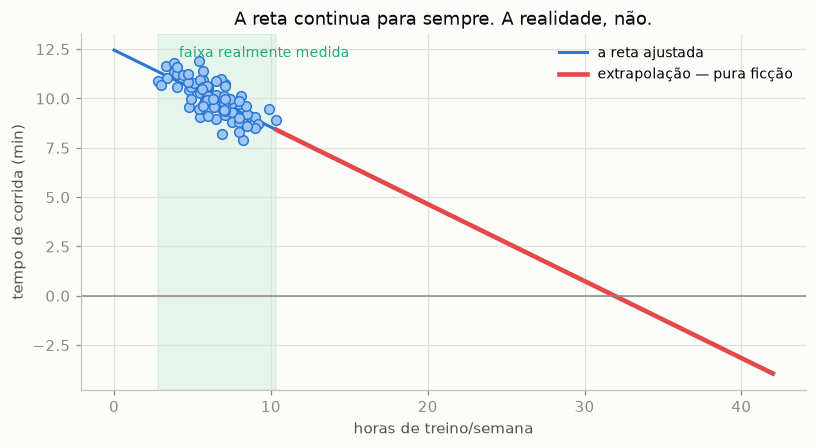

  8 h/semana -> tempo previsto =   9.33 min  <-- dentro dos dados
 12 h/semana -> tempo previsto =   7.77 min  <-- EXTRAPOLAÇÃO
 20 h/semana -> tempo previsto =   4.65 min  <-- EXTRAPOLAÇÃO
 40 h/semana -> tempo previsto =  -3.15 min  <-- EXTRAPOLAÇÃO
 60 h/semana -> tempo previsto = -10.96 min  <-- EXTRAPOLAÇÃO

A companhia treina de 2.8 a 10.3 h/semana. Fora disso a reta está
apenas repetindo uma regra que ninguém verificou — e com 60 h ela prevê tempo NEGATIVO.

O modelo nunca avisa que saiu da faixa. Quem tem que saber é você.


In [8]:
# --- A reta não sabe onde ela deixa de valer ---
grade = np.linspace(0, 42, 200)
prev = a1 * grade + b1

plt.figure(figsize=(8.5, 4.2))
plt.axvspan(h.min(), h.max(), color=COR["verdade"], alpha=0.10)
plt.annotate("faixa realmente medida", xy=(h.mean() - 2.2, 12.1), color="#1baf7a", fontsize=9)
plt.scatter(h, t, color=COR["dados"], edgecolor=COR["reta"], s=40, zorder=3)
plt.plot(grade, prev, color=COR["reta"], label="a reta ajustada")
plt.plot(grade[grade > h.max()], prev[grade > h.max()], color=COR["alerta"],
         linewidth=3, label="extrapolação — pura ficção")
plt.axhline(0, color="#898781", linewidth=1)
plt.title("A reta continua para sempre. A realidade, não.", color="#0b0b0b")
plt.xlabel("horas de treino/semana"); plt.ylabel("tempo de corrida (min)")
plt.legend(frameon=False, fontsize=9)
plt.show()

for hh in [8, 12, 20, 40, 60]:
    marca = "  <-- dentro dos dados" if h.min() <= hh <= h.max() else "  <-- EXTRAPOLAÇÃO"
    print(f"{hh:>3} h/semana -> tempo previsto = {a1 * hh + b1:>6.2f} min{marca}")

print(f"\nA companhia treina de {h.min():.1f} a {h.max():.1f} h/semana. Fora disso a reta está")
print("apenas repetindo uma regra que ninguém verificou — e com 60 h ela prevê tempo NEGATIVO.")
print("\nO modelo nunca avisa que saiu da faixa. Quem tem que saber é você.")

---
# ⑤ Regressão à média

Esta seção sozinha justifica o módulo. É o mecanismo estatístico por trás de **incontáveis**
decisões de comando tomadas sobre um efeito que nunca existiu.

> Após o TAF, o comandante seleciona os **10 piores** e aplica treinamento corretivo intensivo.
> No TAF seguinte, os 10 melhoraram bastante. O treinamento corretivo **funcionou**.

O problema: os 10 melhorariam **de qualquer jeito** — mesmo sem treinamento nenhum. Vamos provar
isso simulando um mundo em que o treinamento corretivo **não existe**.

In [8]:
# --- Um mundo SEM nenhuma intervenção: só habilidade real + acaso do dia ---
rng6 = np.random.default_rng(23)
M = 200

habilidade = rng6.normal(50, 6, M)              # a capacidade real de cada militar (não muda)
taf_1 = habilidade + rng6.normal(0, 5, M)       # dia 1: habilidade + acaso (sono, clima, azar)
taf_2 = habilidade + rng6.normal(0, 5, M)       # dia 2: MESMA habilidade, novo acaso

# NENHUM treinamento aconteceu entre os dois testes. Nada. Zero.
piores = np.argsort(taf_1)[:10]                 # os 10 piores do TAF 1
melhores = np.argsort(taf_1)[-10:]              # os 10 melhores do TAF 1


print("O número no interior da tabela abaixo é um escore de 0 a 100 criado da minha cabeça (pode ser nota do TAF).\n")
print("NENHUMA intervenção foi aplicada entre o TAF 1 e o TAF 2.\n")
print(f"{'grupo':<26} | {'TAF 1':>7} | {'TAF 2':>7} | {'mudança':>8}")
print("-" * 56)
for rotulo, idx in [("os 10 PIORES do TAF 1", piores),
                    ("os 10 MELHORES do TAF 1", melhores),
                    ("a companhia inteira", np.arange(M))]:
    m1, m2 = taf_1[idx].mean(), taf_2[idx].mean()
    print(f"{rotulo:<26} | {m1:>7.2f} | {m2:>7.2f} | {m2 - m1:>+8.2f}")

g_pior = taf_2[piores].mean() - taf_1[piores].mean()
g_melh = taf_2[melhores].mean() - taf_1[melhores].mean()
print(f"\nOs piores MELHORARAM {g_pior:.1f} pontos. Os melhores PIORARAM {abs(g_melh):.1f} pontos.")
print("Sem intervenção alguma. A companhia inteira ficou parada — porque nada de fato mudou.")

O número no interior da tabela abaixo é um escore de 0 a 100 criado da minha cabeça (pode ser nota do TAF).

NENHUMA intervenção foi aplicada entre o TAF 1 e o TAF 2.

grupo                      |   TAF 1 |   TAF 2 |  mudança
--------------------------------------------------------
os 10 PIORES do TAF 1      |   33.59 |   40.64 |    +7.05
os 10 MELHORES do TAF 1    |   64.05 |   58.86 |    -5.19
a companhia inteira        |   49.75 |   49.93 |    +0.19

Os piores MELHORARAM 7.1 pontos. Os melhores PIORARAM 5.2 pontos.
Sem intervenção alguma. A companhia inteira ficou parada — porque nada de fato mudou.


### Por que isso acontece

Todo desempenho medido é **habilidade real + acaso do dia**. Para alguém aparecer entre os 10
piores, em geral as duas coisas conspiraram: ele é mesmo mais fraco **e** teve um dia ruim.

Na medição seguinte, a habilidade continua lá — mas o **azar não se repete** (ele é aleatório).
Só isso já puxa o resultado para cima. O mesmo vale, ao contrário, para quem foi destaque: parte
do destaque era sorte, e a sorte não se repete.

> ### ⚠️ A consequência prática, e ela é séria
> **Selecionar por extremo e comparar depois cria um efeito falso — sempre, e na direção
> conveniente.** Quem trata os piores vê melhora; quem premia os melhores vê queda.
>
> Isso "prova" duas coisas falsas de uma vez: que **punir/corrigir funciona** e que
> **elogiar/premiar atrapalha**. É um dos erros mais caros da gestão baseada em número.
>
> **A defesa é uma só: grupo de controle.** Selecione os 20 piores, dê o treinamento a 10
> (sorteados) e a nenhum dos outros 10. A melhora que interessa é a **diferença entre os dois
> grupos** — não a melhora do grupo tratado. Isso é o Módulo 6, §④.

O conceito estatístico de retorno (ou regressão) à média ilustrado com a história de instrutores e cadetes da Força Aérea de Israel (pilotos) é amplamente famoso e aparece no livro "O Andar do Bêbado". Sendo a história mais ou menos assim:

- A história: Kahneman dava aula para instrutores de voo militares e defendia que elogiar o acerto funciona melhor do que xingar o erro.
- A objeção: Um instrutor retrucou dizendo que, quando elogiava uma manobra perfeita, o piloto piorava na tentativa seguinte; e quando gritava com um cadete por uma manobra malfeita, ele melhorava depois.
- A explicação: O instrutor confundiu o acaso com o seu feedback. Quem faz uma manobra perfeita teve um golpe de sorte (estava acima da média) e a tendência natural é piorar na próxima vez (retornar à média). Quem vai muito mal tende a melhorar na próxima tentativa pelo mesmo motivo estatístico, e não porque levou bronca.

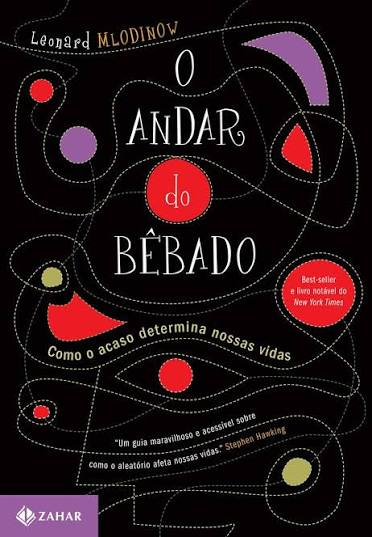

In [7]:
from IPython.display import Image
Image("../imagens/andar_bebado.jpeg", width=300)

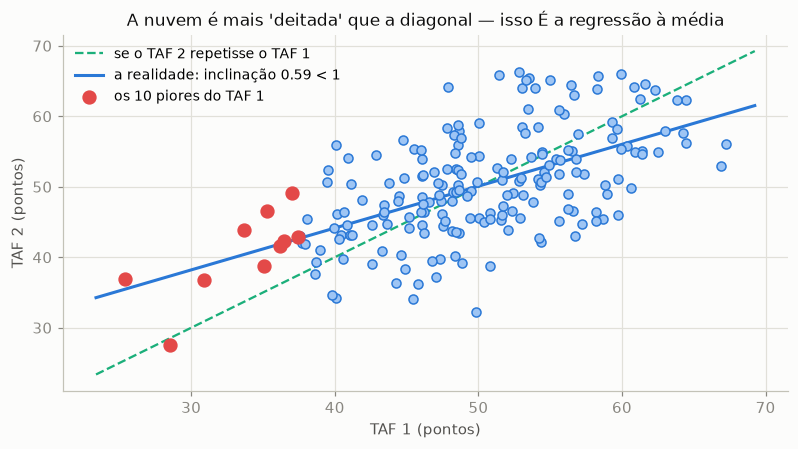

Inclinação da reta = 0.59. Se o desempenho fosse pura habilidade, seria 1,00.
Quanto MAIS acaso houver na medição, mais deitada fica a reta e maior o efeito falso.

O nome 'regressão' vem daí: Galton, 1886, observando que filhos de pais muito altos
eram altos, mas MENOS altos que os pais — um 'retorno em direção à média'.


In [10]:
# --- O mesmo fato, em gráfico ---
plt.figure(figsize=(8.5, 4.2))
plt.scatter(taf_1, taf_2, color=COR["dados"], edgecolor=COR["reta"], s=35, zorder=3)

lim = [taf_1.min() - 2, taf_1.max() + 2]
plt.plot(lim, lim, color=COR["verdade"], linestyle="--", linewidth=1.5,
         label="se o TAF 2 repetisse o TAF 1")
aa, bb = np.polyfit(taf_1, taf_2, 1)
plt.plot(np.array(lim), aa * np.array(lim) + bb, color=COR["reta"],
         label=f"a realidade: inclinação {aa:.2f} < 1")
plt.scatter(taf_1[piores], taf_2[piores], color=COR["alerta"], s=70, zorder=4,
            label="os 10 piores do TAF 1")

plt.title("A nuvem é mais 'deitada' que a diagonal — isso É a regressão à média",
          color="#0b0b0b", fontsize=11)
plt.xlabel("TAF 1 (pontos)"); plt.ylabel("TAF 2 (pontos)")
plt.legend(frameon=False, fontsize=9)
plt.show()

print(f"Inclinação da reta = {aa:.2f}. Se o desempenho fosse pura habilidade, seria 1,00.")
print("Quanto MAIS acaso houver na medição, mais deitada fica a reta e maior o efeito falso.")
print("\nO nome 'regressão' vem daí: Galton, 1886, observando que filhos de pais muito altos")
print("eram altos, mas MENOS altos que os pais — um 'retorno em direção à média'.")

---
# ⑥ Decisão: prever **não** é explicar

Um modelo de regressão pode ser excelente para **prever** e completamente inútil para **decidir
o que fazer** — porque prever exige apenas que a associação continue existindo, enquanto agir
exige que a relação seja **causal**.

| A pergunta real é... | Reporte | Cuidado |
|---|---|---|
| "sobe quanto?" | o **coeficiente com unidade** | o `r` não responde isso (§⓪) |
| "quanto vale a previsão?" | `r²` **e** o erro típico (desvio dos resíduos) | `r²` alto não valida a forma |
| "o modelo está certo?" | o **gráfico de resíduos** | nenhum número substitui esse gráfico (§③) |
| "e para um caso extremo?" | a **faixa medida** | fora dela é ficção (§④) |
| "esse efeito é real?" | **quais variáveis** estão no modelo | o coeficiente muda com elas (§2.2) |
| "o corretivo funcionou?" | a **diferença contra um controle** | sem controle, é regressão à média (§⑤) |

### Três frases para levar

1. **Mínimos quadrados é a média generalizada** — e herda tudo dela, inclusive a fragilidade a
   um ponto extremo.
2. **Os resíduos são o diagnóstico.** O `r²` não denuncia curva; o gráfico de resíduos sim.
3. **Selecionar pelo extremo fabrica efeito.** Sem grupo de controle, você está medindo o acaso
   voltando ao normal.

---
# ⑦ Exercícios

**Exercício 1 — Preveja antes de rodar.**

Sem executar nada:

1. Se eu medir o tempo em **segundos** em vez de minutos, o que acontece com a inclinação? E com
   o `r`?
2. Se eu acrescentar ao Modelo 2 uma variável **irrelevante** (o número do CPF, digamos), o que
   acontece com o `r²`?
3. No gráfico do TAF 1 × TAF 2, o que aconteceria com a inclinação se o teste fosse **muito mais
   preciso** (menos acaso no dia)?

**Exercício 2 — Mude um parâmetro.**

Na célula da §⑤, mude o desvio do acaso de `5` para `1` e depois para `12` (nas duas linhas do
TAF). Anote a "melhora" dos 10 piores em cada caso. Pergunta: qual é a relação entre a
**quantidade de acaso** na medição e o tamanho do efeito falso?

**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

Um relatório traz:

> "O modelo `tempo = 12,4 − 0,42 × horas_treino` tem r² = 0,58. Portanto, para um militar chegar
> a 8 minutos, basta treinar **10,5 horas por semana**. Recomendamos fixar essa meta para toda a
> OM."

Há **três** erros conceituais. Encontre os três. *(Dicas: §④, §2.2, §⑥.)*

**Exercício 4 — Interprete (discussão em grupo).**

O S1 apresenta: *"regredimos o número de faltas disciplinares contra as horas de instrução de
liderança. O coeficiente deu −0,8 falta por hora, com r² = 0,64. Cada hora de instrução evita
0,8 falta; propomos triplicar a carga de instrução."*

1. O que significaria "triplicar" em termos da §④?
2. Que variável **não medida** poderia explicar as duas coisas ao mesmo tempo? (isso é o
   Módulo 6)
3. As OMs com mais faltas foram as que **receberam mais instrução**? Se sim, qual seção deste
   módulo se aplica?
4. Que desenho de estudo permitiria afirmar que a instrução **causa** a redução?

---
## Resumo do módulo

| Ferramenta | Para quê | Cuidado |
|---|---|---|
| **Inclinação** | "sobe quanto" — tem unidade | é associação, não efeito causal |
| **Intercepto** | valor previsto em x = 0 | quase sempre fora dos dados |
| **`r²`** | fração da variação explicada | não valida a **forma** do modelo |
| **Gráfico de resíduos** | diagnóstico do ajuste | é obrigatório, não opcional |
| **Regressão múltipla** | separar efeitos sobrepostos | só ajusta o que você **mediu** |
| **Faixa dos dados** | onde o modelo vale | fora dela: extrapolação |

- **A reta é a média condicionada a x.** Mesma régua do quadrado, mesmas heranças.
- **O coeficiente muda conforme o modelo** — e isso é significado, não erro.
- **Regressão à média** transforma acaso em "efeito"; só o grupo de controle desmascara.

➡️ **Próximo módulo:** tudo neste módulo foi **associação**. Toda vez que alguém deu o passo
seguinte — "então o treino **causa** a melhora" — nós paramos e adiamos a discussão. O Módulo 6
é essa discussão: por que dado observacional quase nunca autoriza falar em causa, e o que seria
preciso para autorizar.